<div>
 
  <b>Escuela Politécnica Nacional</b><br>
  <small>Facultad de Ingeniería de Sistemas</small><br>
  <small>Ingeniería en Ciencias de la Computación</small>
 
  <hr>
 
  <div style="display:flex; justify-content:space-between;">
    <div>
      Estudiante: <b>Mateo Cumbal</b><br>
      Fecha: <b>2026-07-12</b>
    </div>
    <div style="text-align:right;">
      Asignatura: <b>Recuperación de la Información</b><br>
      Paralelo: <b>GR1CC</b>
    </div>
  </div>
 
  <hr>
 
  <div style="text-align:center;">
    <h1><b>Ejercicio 12 — Embeddings Multimodales con CLIP</b></h1>
  </div>
 
</div>

## Objetivo de la práctica

Observar cómo un modelo multimodal como CLIP lleva texto e imágenes al mismo espacio vectorial, y verificar ese comportamiento generando embeddings, proyectándolos en 2D y evaluando emparejamientos con similitud coseno.

**Pasos:**
1. Obtener embeddings de imágenes y textos con CLIP.
2. Confirmar que ambas modalidades comparten espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA) y graficarlos.
4. Verificar emparejamientos con similitud coseno (búsqueda texto→imagen e imagen→texto).

**Dataset:** muestra de 10 pares imagen-caption de Flickr8k, elegida deliberadamente con 2 pares temáticamente similares (perros, piscina) y 6 categorías distintas entre sí. Esto permite observar tanto la discriminación fina entre imágenes parecidas como el matching general frente a categorías completamente distintas.

### 1. Configuración

In [ ]:
# !pip install kaggle transformers torch pillow scikit-learn matplotlib pandas

In [1]:
import os
import gc

import pandas as pd
import numpy as np
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from IPython.display import display

c:\Users\Acer123\venvs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Descarga del dataset (Flickr8k)

Se usa Flickr8k por tener imágenes reales con captions humanos ya etiquetados, sin necesidad de redactar descripciones a mano. La descarga asume que `kaggle.json` ya está configurado en `~/.kaggle/` — las credenciales nunca van en el notebook ni en el repositorio.

In [ ]:
# !kaggle datasets download -d aladdinpersson/flickr8kimagescaptions -p ../../extras/flickr8k --unzip

### 3. Estructura del dataset

In [2]:
base_dir = "../../extras/flickr8k"
for root, dirs, files in os.walk(base_dir):
    print(root, "->", dirs, files[:3], f"({len(files)} archivos)" if files else "")

../../extras/flickr8k -> ['flickr8k'] [] 
../../extras/flickr8k\flickr8k -> ['images'] ['captions.txt'] (1 archivos)
../../extras/flickr8k\flickr8k\images -> [] ['1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg', '1002674143_1b742ab4b8.jpg'] (8091 archivos)


### 4. Selección de la muestra

Se eligen 10 pares imagen-caption a mano, no al azar: 2 pares por categoría temática similar (perros, piscina) y 6 categorías distintas entre sí. Esto permite evaluar tanto la discriminación fina de CLIP entre imágenes parecidas como su capacidad de generalización frente a categorías completamente distintas.

Cada imagen se etiqueta con una **categoría legible** (ej. `"perro (pelea)"`) que se usa en los gráficos en vez del ID crudo del archivo — los IDs de Flickr8k no son informativos por sí solos y truncarlos genera ambigüedad entre IDs distintos.

In [3]:
captions_path = "../../extras/flickr8k/flickr8k/captions.txt"
images_dir = "../../extras/flickr8k/flickr8k/images/"

df_captions = pd.read_csv(captions_path)

ids_muestra = [
    "1001773457_577c3a7d70",
    "1056873310_49c665eb22",
    "1057089366_ca83da0877",
    "1119463452_69d4eecd08",
    "1002674143_1b742ab4b8",
    "1057210460_09c6f4c6c1",
    "1095980313_3c94799968",
    "1121416483_c7902d0d49",
    "1056359656_662cee0814",
    "118187095_d422383c81",
]

categorias_muestra = [
    "perro (pelea)",
    "perro (corriendo)",
    "niño (piscina)",
    "niña (piscina)",
    "niña (pintura)",
    "hombre (camisa)",
    "niña (playa)",
    "niña (cama)",
    "niña (tren)",
    "niños (desfile)",
]

muestra = []
for img_id, categoria in zip(ids_muestra, categorias_muestra):
    filename = f"{img_id}.jpg"
    caption = df_captions[df_captions["image"] == filename]["caption"].iloc[0].strip()
    muestra.append(
        {"image_id": img_id, "categoria": categoria, "filename": filename, "caption": caption}
    )

df_muestra = pd.DataFrame(muestra)
df_muestra

,image_id,categoria,filename,caption
0,1001773457_577c3a7d70,perro (pelea),1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
1,1056873310_49c665eb22,perro (corriendo),1056873310_49c665eb22.jpg,A brown dog is running after a black dog on a ...
2,1057089366_ca83da0877,niño (piscina),1057089366_ca83da0877.jpg,A boy descends off the end of a high diving bo...
3,1119463452_69d4eecd08,niña (piscina),1119463452_69d4eecd08.jpg,A girl in a pink swimsuit in a pool
4,1002674143_1b742ab4b8,niña (pintura),1002674143_1b742ab4b8.jpg,A little girl covered in paint sits in front o...
5,1057210460_09c6f4c6c1,hombre (camisa),1057210460_09c6f4c6c1.jpg,A guy stands by a window taking his overshirt ...
6,1095980313_3c94799968,niña (playa),1095980313_3c94799968.jpg,A little girl in a blue swimsuit is walking al...
7,1121416483_c7902d0d49,niña (cama),1121416483_c7902d0d49.jpg,A child is standing on her head .
8,1056359656_662cee0814,niña (tren),1056359656_662cee0814.jpg,A little girl looking at a brochure on train r...
9,118187095_d422383c81,niños (desfile),118187095_d422383c81.jpg,Parents are pushing little children in red car...


### 5. Verificación de integridad

In [4]:
faltantes = [f for f in df_muestra["filename"] if not os.path.exists(os.path.join(images_dir, f))]
assert len(faltantes) == 0, f"Faltan: {faltantes}"
print("Todas las imágenes de la muestra existen.")

Todas las imágenes de la muestra existen.


### 6. Carga del modelo CLIP

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

modelo_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor_clip = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
modelo_clip.eval()
print("Modelo CLIP cargado.")

Usando dispositivo: cuda


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 32421.16it/s]


Modelo CLIP cargado.


### 7. Funciones de embedding

CLIP proyecta imagen y texto al mismo espacio de 512 dimensiones mediante `get_image_features` y `get_text_features`. Cada vector se normaliza (norma L2 = 1) para que la similitud coseno posterior sea directa. La extracción del tensor se maneja de forma robusta porque distintas versiones de `transformers` devuelven formatos distintos (tensor directo vs. objeto con atributo `.image_embeds` / `.text_embeds`).

In [8]:
def obtener_embedding_imagen(filename: str) -> np.ndarray:
    """
    Genera el embedding CLIP de una imagen.
    """
    ruta = os.path.join(images_dir, filename)
    imagen = Image.open(ruta).convert("RGB")

    inputs = processor_clip(images=imagen, return_tensors="pt").to(device)

    with torch.no_grad():
        salida = modelo_clip.get_image_features(**inputs)

    # 1. Extracción robusta del tensor de PyTorch
    if hasattr(salida, "image_embeds") and salida.image_embeds is not None:
        embedding = salida.image_embeds
    elif hasattr(salida, "pooler_output") and salida.pooler_output is not None:
        embedding = salida.pooler_output
    elif isinstance(salida, torch.Tensor):
        embedding = salida
    else:
        raise ValueError("El modelo no devolvió un tensor reconocible.")

    # 2. Normalización (ahora embedding sí es un torch.Tensor garantizado)
    embedding = embedding / embedding.norm(p=2, dim=-1, keepdim=True)
    return embedding.cpu().numpy().flatten()


def obtener_embedding_texto(texto: str) -> np.ndarray:
    """
    Genera el embedding CLIP de un texto.
    """
    inputs = processor_clip(text=[texto], return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        salida = modelo_clip.get_text_features(**inputs)

    # 1. Extracción robusta del tensor de PyTorch para texto
    if hasattr(salida, "text_embeds") and salida.text_embeds is not None:
        embedding = salida.text_embeds
    elif hasattr(salida, "pooler_output") and salida.pooler_output is not None:
        embedding = salida.pooler_output
    elif isinstance(salida, torch.Tensor):
        embedding = salida
    else:
        raise ValueError("El modelo no devolvió un tensor reconocible.")

    # 2. Normalización
    embedding = embedding / embedding.norm(p=2, dim=-1, keepdim=True)
    return embedding.cpu().numpy().flatten()

### 8. Generación y verificación del espacio compartido

In [9]:
embeddings_img = np.array([obtener_embedding_imagen(fn) for fn in df_muestra["filename"]])
embeddings_txt = np.array([obtener_embedding_texto(cap) for cap in df_muestra["caption"]])

print(f"Shape embeddings imagen : {embeddings_img.shape}")
print(f"Shape embeddings texto  : {embeddings_txt.shape}")
assert embeddings_img.shape == embeddings_txt.shape

print(f"Normas imagen (≈1.0): {np.linalg.norm(embeddings_img, axis=1)}")
print(f"Normas texto  (≈1.0): {np.linalg.norm(embeddings_txt, axis=1)}")

gc.collect()

Shape embeddings imagen : (10, 512)
Shape embeddings texto  : (10, 512)
Normas imagen (≈1.0): [1.         1.         0.99999994 1.         1.         1.
 1.         0.99999994 1.         1.0000001 ]
Normas texto  (≈1.0): [0.9999998  1.         1.         1.         1.         1.
 0.99999994 1.         1.         1.        ]


1500

### 9. Proyección PCA 2D

Se proyectan imagen y texto juntos al mismo plano 2D. El objetivo es observar si el espacio se organiza por contenido semántico o por modalidad — este segundo caso (*modality gap*) es un fenómeno documentado en CLIP y no indica una falla del modelo.

In [10]:
todos_embeddings = np.vstack([embeddings_img, embeddings_txt])
etiquetas_tipo = ["imagen"] * len(embeddings_img) + ["texto"] * len(embeddings_txt)
etiquetas_categoria = list(df_muestra["categoria"]) * 2

pca = PCA(n_components=2, random_state=42)
proyeccion_2d = pca.fit_transform(todos_embeddings)

print(f"Varianza explicada (2 componentes): {pca.explained_variance_ratio_.sum():.2%}")

Varianza explicada (2 componentes): 42.17%


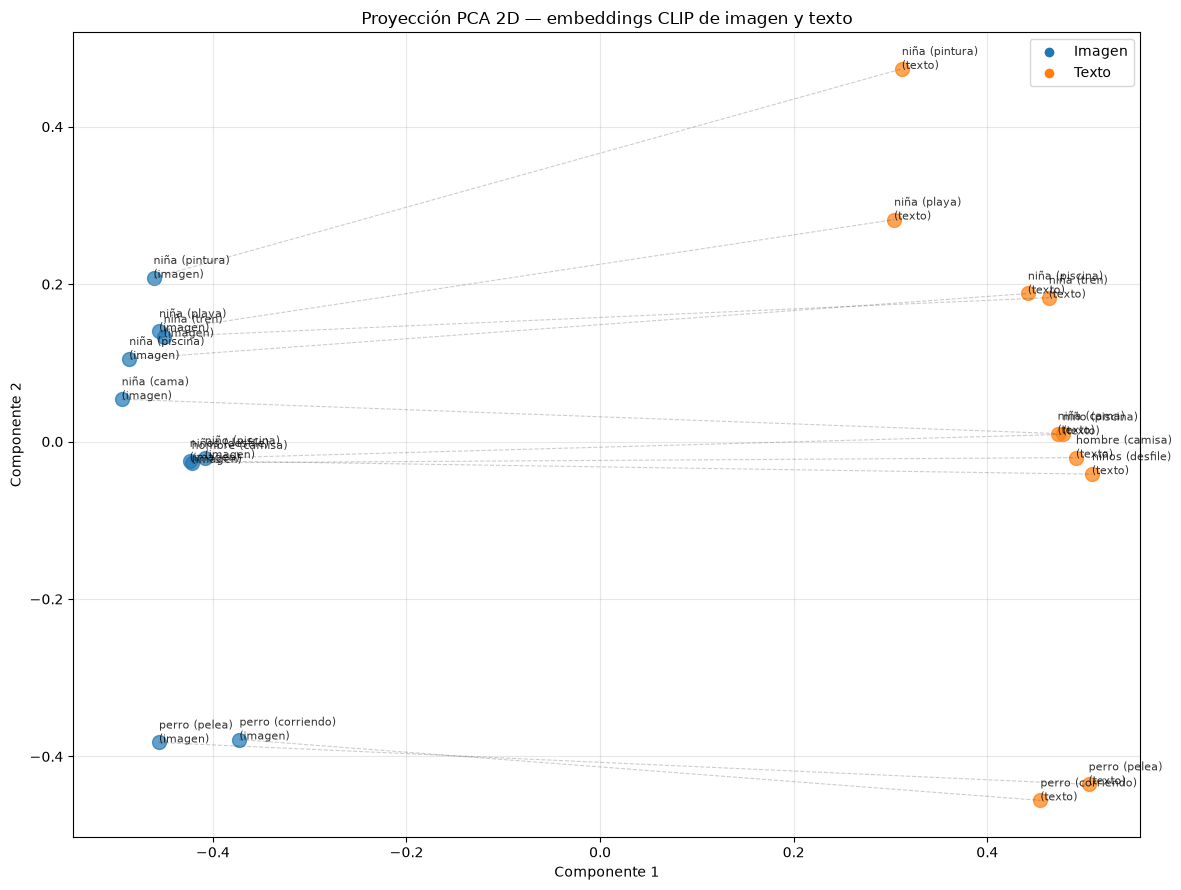

In [11]:
plt.figure(figsize=(12, 9))
colores = {"imagen": "tab:blue", "texto": "tab:orange"}

for i, (x, y) in enumerate(proyeccion_2d):
    tipo = etiquetas_tipo[i]
    plt.scatter(x, y, c=colores[tipo], s=100, alpha=0.7)
    plt.annotate(f"{etiquetas_categoria[i]}\n({tipo})", (x, y), fontsize=8, alpha=0.8)

for i in range(len(embeddings_img)):
    x_img, y_img = proyeccion_2d[i]
    x_txt, y_txt = proyeccion_2d[i + len(embeddings_img)]
    plt.plot([x_img, x_txt], [y_img, y_txt], "k--", alpha=0.2, linewidth=0.8)

plt.scatter([], [], c=colores["imagen"], label="Imagen")
plt.scatter([], [], c=colores["texto"], label="Texto")

plt.title("Proyección PCA 2D — embeddings CLIP de imagen y texto")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 10. Matriz de similitud coseno

Se calcula la similitud coseno sobre las 512 dimensiones completas (sin la pérdida de información del PCA). Si el matching funciona, la diagonal (imagen vs. su propio caption) debe ser el valor más alto de cada fila y columna.

In [12]:
matriz_sim = cosine_similarity(embeddings_img, embeddings_txt)
print(f"Shape matriz de similitud: {matriz_sim.shape}")

Shape matriz de similitud: (10, 10)


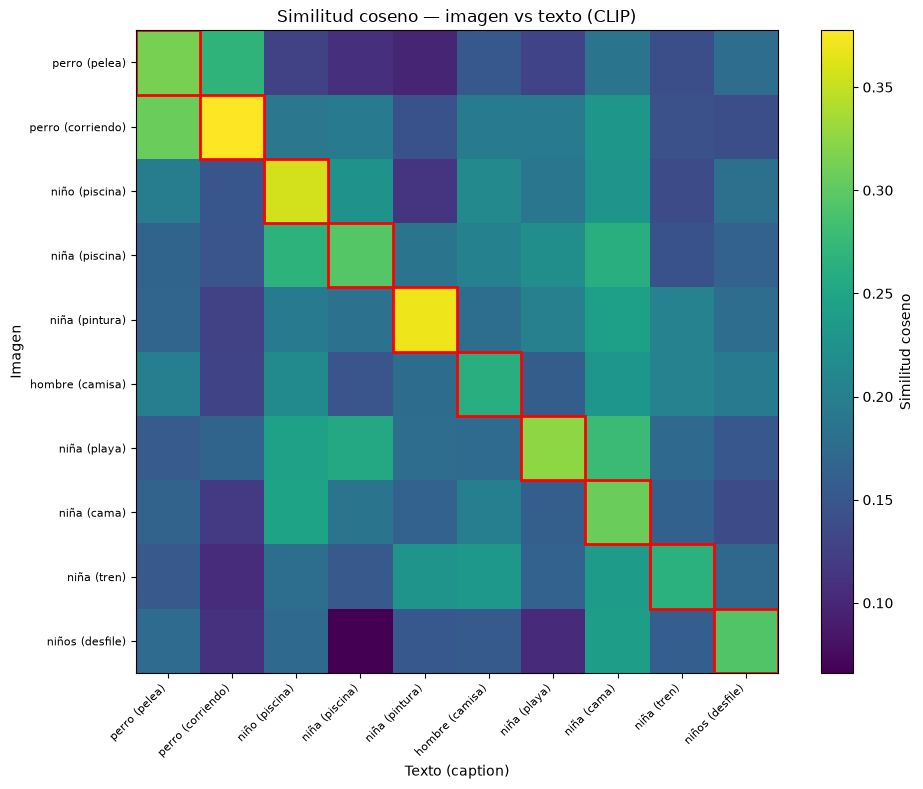

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matriz_sim, cmap="viridis")

etiquetas = df_muestra["categoria"]
ax.set_xticks(range(len(df_muestra)))
ax.set_yticks(range(len(df_muestra)))
ax.set_xticklabels(etiquetas, fontsize=8, rotation=45, ha="right")
ax.set_yticklabels(etiquetas, fontsize=8)
ax.set_xlabel("Texto (caption)")
ax.set_ylabel("Imagen")
ax.set_title("Similitud coseno — imagen vs texto (CLIP)")

for i in range(len(df_muestra)):
    ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2))

plt.colorbar(im, label="Similitud coseno")
plt.tight_layout()
plt.show()

La diagonal (marcada en rojo) concentra el valor más alto en casi todas las filas y columnas, confirmando que cada imagen es más similar a su propio caption que a los demás. Los pares temáticamente similares ("perro (pelea)"/"perro (corriendo)" y las dos categorías de piscina) muestran además similitud cruzada más alta entre sí que con el resto — CLIP distingue el match exacto, pero también agrupa por cercanía semántica dentro del par.

### 11. Búsqueda cruzada texto↔imagen

In [14]:
def buscar_imagen_por_texto(query_texto: str, top_k: int = 3) -> pd.DataFrame:
    """
    Dado un texto libre, retorna las imágenes más similares de la muestra.
    """
    emb_query = obtener_embedding_texto(query_texto)
    sims = cosine_similarity([emb_query], embeddings_img)[0]

    resultado = df_muestra.copy()
    resultado["similitud"] = sims
    return resultado.sort_values("similitud", ascending=False).head(top_k)[
        ["categoria", "image_id", "caption", "similitud"]
    ]


def buscar_texto_por_imagen(idx_imagen: int, top_k: int = 3) -> pd.DataFrame:
    """
    Dada una imagen de la muestra (por índice), retorna los captions más similares.
    """
    emb_query = embeddings_img[idx_imagen]
    sims = cosine_similarity([emb_query], embeddings_txt)[0]

    resultado = df_muestra.copy()
    resultado["similitud"] = sims
    return resultado.sort_values("similitud", ascending=False).head(top_k)[
        ["categoria", "image_id", "caption", "similitud"]
    ]

In [15]:
print("Búsqueda: \'two dogs playing outdoors\' (texto libre, no es un caption exacto)")
display(buscar_imagen_por_texto("two dogs playing outdoors"))

print(f"\nBúsqueda: imagen \'{df_muestra.loc[0, 'categoria']}\' -> mejores captions")
display(buscar_texto_por_imagen(0))

Búsqueda: 'two dogs playing outdoors' (texto libre, no es un caption exacto)


,categoria,image_id,caption,similitud
0,perro (pelea),1001773457_577c3a7d70,A black dog and a spotted dog are fighting,0.292163
1,perro (corriendo),1056873310_49c665eb22,A brown dog is running after a black dog on a ...,0.286977
4,niña (pintura),1002674143_1b742ab4b8,A little girl covered in paint sits in front o...,0.208644



Búsqueda: imagen 'perro (pelea)' -> mejores captions


,categoria,image_id,caption,similitud
0,perro (pelea),1001773457_577c3a7d70,A black dog and a spotted dog are fighting,0.314206
1,perro (corriendo),1056873310_49c665eb22,A brown dog is running after a black dog on a ...,0.268892
7,niña (cama),1121416483_c7902d0d49,A child is standing on her head .,0.185479


La consulta con texto libre ("two dogs playing outdoors") no es un caption literal de la muestra, y aun así recuperó las dos imágenes de perros como resultados más relevantes, muy por encima de la tercera opción. Esto confirma que CLIP generaliza semánticamente en vez de memorizar captions exactos.

## Conclusiones

- CLIP proyecta imágenes y texto al mismo espacio vectorial de 512 dimensiones, confirmado por shapes idénticos y normas L2 ≈ 1.0 en ambas modalidades.

- La proyección PCA 2D mostró una separación clara entre el clúster de imágenes y el clúster de textos (*modality gap*): el eje principal de varianza captura la modalidad antes que el contenido semántico. Es un fenómeno documentado en CLIP, no una falla del modelo.

- Pese a esa separación en 2D, la matriz de similitud coseno sobre las 512 dimensiones completas mostró diagonal dominante: cada imagen resultó más similar a su propio caption que a los demás, validando que el espacio compartido sí codifica la relación semántica imagen-texto.

- Los pares temáticamente similares ("perro (pelea)" / "perro (corriendo)" y "niño (piscina)" / "niña (piscina)") mostraron mayor similitud cruzada entre sí que con el resto de la muestra, evidenciando que CLIP agrupa por contenido visual/semántico afín, aunque sigue discriminando correctamente el match exacto dentro de cada par.

- La búsqueda con texto libre ("two dogs playing outdoors", que no es un caption literal de la muestra) recuperó correctamente las dos imágenes de perros como resultados más relevantes, confirmando que el modelo generaliza semánticamente en vez de memorizar captions exactos.